## Homework B06: Gaussian Process for island tools.  Add Guassian process for log-population.
By Prabhakar Srivastava

In [1]:
# Import libraries
import pandas as pd
import numpy as np
from numpy.random import default_rng
import matplotlib.pyplot as plt
import preliz as pz
import pytensor.tensor as pt
import pymc as pm
import arviz as az

Random Seed and plotting style

In [2]:
seed_ = sum(map(ord, "Statistical Rethinking Homework B06 Gaussian Process Islands"))
random_seed = default_rng(seed_)

plt.style.use("statistical-rethinking-2023.mplstyle")

Import the data

In [3]:
file_path_str:str = "https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/islands.csv"

islands_df = pd.read_csv(file_path_str, sep=";")
islands_df

,culture,population,contact,total_tools,mean_TU
0,Malekula,1100,low,13,3.2
1,Tikopia,1500,low,22,4.7
2,Santa Cruz,3600,low,24,4.0
3,Yap,4791,high,43,5.0
4,Lau Fiji,7400,high,33,5.0
5,Trobriand,8000,high,19,4.0
6,Chuuk,9200,high,40,3.8
7,Manus,13000,low,28,6.6
8,Tonga,17500,high,55,5.4
9,Hawaii,275000,low,71,6.6


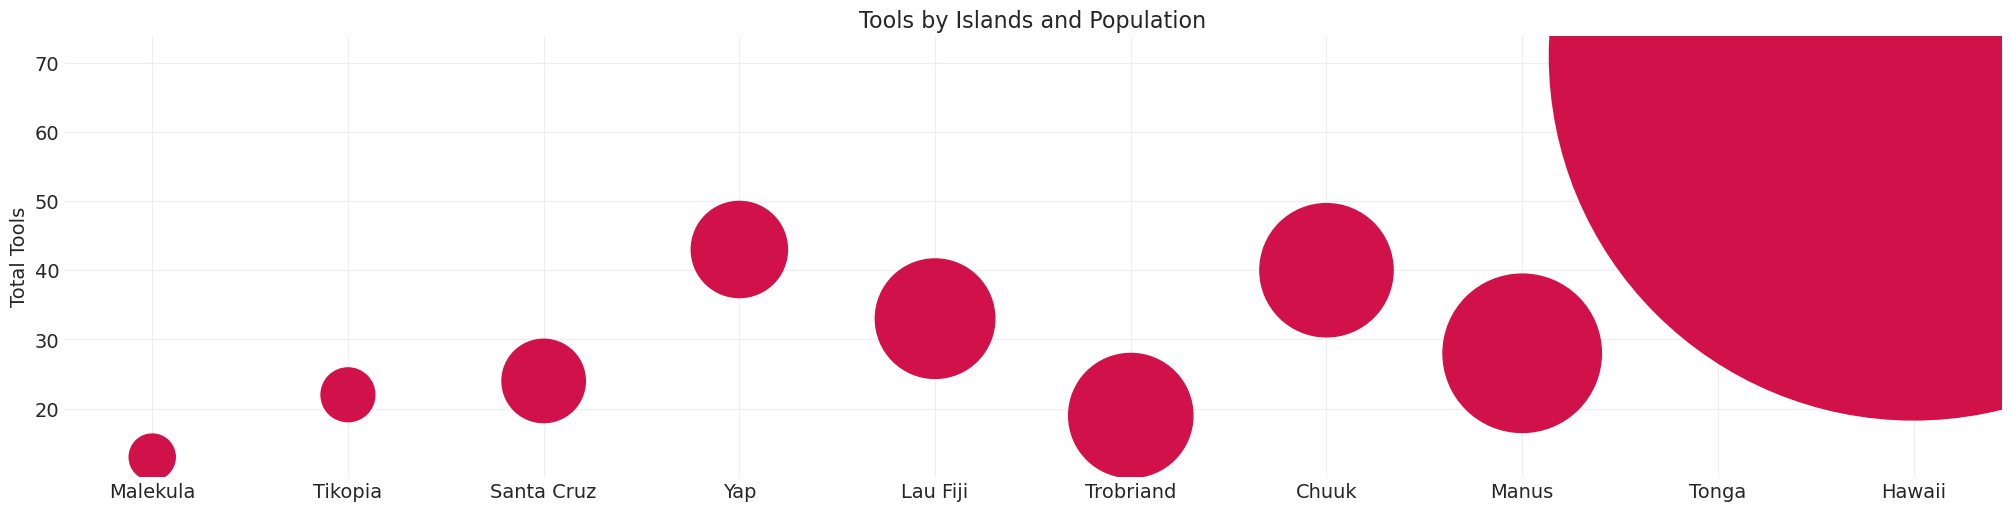

In [4]:
fig, ax = plt.subplots(figsize=(20, 5))

(
    islands_df
    .assign(log_pop = lambda z: np.log10(z["population"]))
    .sort_values(by = "population")
    .plot(x="culture", 
          y="total_tools",
          s="population",
          kind="scatter",
          ax=ax
         )
)
ax.set(xlabel="", ylabel="Total Tools", title="Tools by Islands and Population")
plt.show()

Import the distance matrix

In [5]:
islands_distance = pd.read_csv("islands_distance_matrix.csv", sep=";")

In [6]:
islands_distance

,Malekula,Tikopia,Santa Cruz,Yap,Lau Fiji,Trobriand,Chuuk,Manus,Tonga,Hawaii
0,0.000,0.475,0.631,4.363,1.234,2.036,3.178,2.794,1.860,5.678
1,0.475,0.000,0.315,4.173,1.236,2.007,2.877,2.670,1.965,5.283
2,0.631,0.315,0.000,3.859,1.550,1.708,2.588,2.356,2.279,5.401
3,4.363,4.173,3.859,0.000,5.391,2.462,1.555,1.616,6.136,7.178
4,1.234,1.236,1.550,5.391,0.000,3.219,4.027,3.906,0.763,4.884
5,2.036,2.007,1.708,2.462,3.219,0.000,1.801,0.850,3.893,6.653
6,3.178,2.877,2.588,1.555,4.027,1.801,0.000,1.213,4.789,5.787
7,2.794,2.670,2.356,1.616,3.906,0.850,1.213,0.000,4.622,6.722
8,1.860,1.965,2.279,6.136,0.763,3.893,4.789,4.622,0.000,5.037
9,5.678,5.283,5.401,7.178,4.884,6.653,5.787,6.722,5.037,0.000


Let us download the version of the data from Osvaldo Martin, Bayesian Data Analysis with Python 3rd Edition (2024)

In [7]:
islands_df = pd.read_csv("https://raw.githubusercontent.com/aloctavodia/BAP3/main/code/data/islands.csv")
islands_df["logpop"] = islands_df["logpop"]/islands_df["logpop"].max()
islands_df

,culture,total_tools,lat,lon,logpop
0,Malekula,13,-16.3,-12.5,0.559148
1,Tikopia,22,-12.3,-11.2,0.583912
2,Santa Cruz,24,-10.7,-14.0,0.653812
3,Yap,43,9.5,-41.9,0.676632
4,Lau Fiji,33,-17.7,-1.9,0.711343
5,Trobriand,19,-8.7,-29.1,0.717568
6,Chuuk,40,7.4,-28.4,0.728727
7,Manus,28,-2.1,-33.1,0.756332
8,Tonga,55,-21.2,4.8,0.780066
9,Hawaii,71,19.9,24.4,1.000000


The Model <br>
<center> $T_i \sim \text{Poisson}(\lambda_i)$ </center> <br>
<center> $\lambda_i = \bar{\alpha} + \alpha_{Distance_{S[i]}} + \alpha_{logpop_{S[i]}}$ </center> <br>
<center> $\begin{pmatrix} \alpha_0 \\ \alpha_1 \\ \vdots \\ \alpha_9 \end{pmatrix} = 
\text{MVNormal}(\begin{pmatrix} 0 \\ 0 \\ \vdots \\ 0 \end{pmatrix}, \textbf{K})$ </center> <br>
$\textbf{K}$ is the Kernel for the Gaussian Process

Helper functions I found from book Bayesian Data Analysis with Python Third Edition, 2024 by Osvaldo Martin

In [8]:
def get_ig_params(x_vals, l_b=None, u_b=None, mass=0.95, plot=False):
    '''
    Obtain weakly informative priors for the inverse gamma distribution to use in GPs
    '''

    differences = np.abs(np.subtract.outer(x_vals, x_vals))

    if l_b is None:
        l_b = np.min(differences[differences!=0]) * 2
    if u_b is None:
        u_b = np.max(differences)/1.5

    dist = pz.InverseGamma()
    pz.maxent(dist, l_b, u_b, mass, plot=plot)

    return dict(zip(dist.param_names, dist.params))

In [9]:
def haversine_dist(lat, lon, r=6.371):

    lat = np.radians(lat)
    lon = np.radians(lon)

    latd = lat[:, None] - lat
    lond = lon[:, None] - lon

    d = np.cos(lat[:, None]) * np.cos(lat)
    a = np.sin(latd / 2)**2 + d * np.sin(lond / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return r * c

In [10]:
X = islands_df[["lat", "lon"]].values
islands_dist = haversine_dist(X[:, 0], X[:, 1])

In [11]:
islands_dist.round(2)

array([[0.  , 0.47, 0.64, 4.32, 1.14, 1.99, 3.16, 2.75, 1.9 , 5.7 ],
       [0.47, 0.  , 0.35, 4.17, 1.17, 2.  , 2.9 , 2.67, 1.97, 5.29],
       [0.64, 0.35, 0.  , 3.82, 1.52, 1.67, 2.57, 2.32, 2.32, 5.41],
       [4.32, 4.17, 3.82, 0.  , 5.33, 2.47, 1.5 , 1.62, 6.14, 7.18],
       [1.14, 1.17, 1.52, 5.33, 0.  , 3.11, 4.03, 3.82, 0.8 , 5.07],
       [1.99, 2.  , 1.67, 2.47, 3.11, 0.  , 1.79, 0.86, 3.89, 6.66],
       [3.16, 2.9 , 2.57, 1.5 , 4.03, 1.79, 0.  , 1.18, 4.82, 5.85],
       [2.75, 2.67, 2.32, 1.62, 3.82, 0.86, 1.18, 0.  , 4.62, 6.73],
       [1.9 , 1.97, 2.32, 6.14, 0.8 , 3.89, 4.82, 4.62, 0.  , 5.04],
       [5.7 , 5.29, 5.41, 7.18, 5.07, 6.66, 5.85, 6.73, 5.04, 0.  ]])

In [12]:
# ExpQuadHaversine
class ExpQuadHaversine(pm.gp.cov.Stationary):
    def __init__(self, input_dims, ls, ls_inv=None, r=6.371, active_dims=None):
        super().__init__(input_dims, ls=ls, ls_inv=ls_inv, active_dims=active_dims)
        self.r = r

    def haversine_distance(self, X):
        lat = np.radians(X[:, 0])
        lon = np.radians(X[:, 1])

        latd = lat[:, None] - lat
        lond = lon[:, None] - lon

        d = pt.cos(lat[:, None]) * pt.cos(lat)
        a = pt.sin(latd / 2)**2 + d * pt.sin(lond / 2)**2
        c = 2 * pt.arctan2(pt.sqrt(a), pt.sqrt(1 - a))

        return self.r * c

    def full(self, X, _):
        return pt.exp(-0.5 * self.haversine_distance(X))

Begin the PyMC Model

In [13]:
# Coordinates
islands_id, islands = pd.factorize(islands_df["culture"])
COORDS = {"islands": islands}

Appropriate Priors

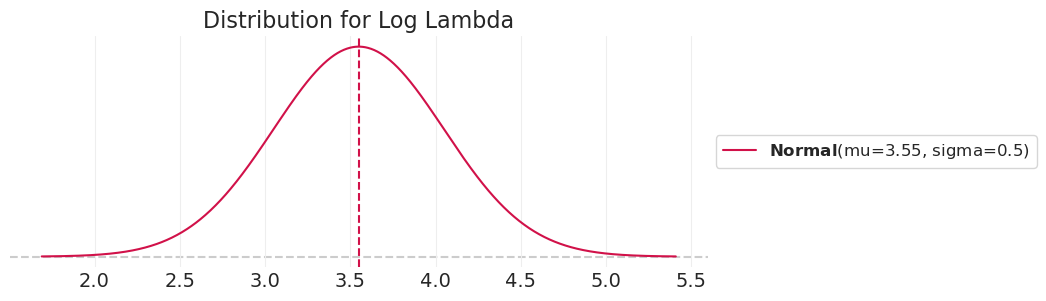

In [14]:
_, ax = plt.subplots(figsize=(9, 3))
log_lam = np.log(islands_df["total_tools"].mean())
dist = pz.Normal(log_lam, 0.5)
dist.plot_pdf(ax=ax)
ax.axvline(log_lam, ls="--")
ax.set_title("Distribution for Log Lambda")
plt.show()

In [15]:
with pm.Model(coords=COORDS) as islands_model:

    # Priors
    α_bar = pm.Normal("α_bar", log_lam, 0.5) # Intercept

    # Priors for Spatial Variation: Largely using those given by the examples
    η = pm.Exponential("η", 2)
    ls= pm.InverseGamma("ls", **get_ig_params(islands_dist))
    kernel_func = (η) * ExpQuadHaversine(input_dims=2, ls=ls)
    gp_dist = pm.gp.Latent(cov_func=kernel_func)
    α_dist = gp_dist.prior("α_dist", X=X, dims="islands")
    
    # Priors for GP on log-population: Let us try a Gaussian Kernel
    η_1 = pm.Exponential("η_1", 1)
    ℓ = pm.InverseGamma("ℓ", **get_ig_params(islands_df["logpop"].values))
    # Kernel function: should have dims of islands, islands. 
    K_log_pop = (η_1) * pm.gp.cov.ExpQuad(input_dim=1, ls=ℓ)
    gp_log_pop = pm.gp.Latent(cov_func=K_log_pop)
    α_log_pop = gp_log_pop.prior("α_log_pop", X=islands_df["logpop"].values[:, None], dims="islands")

    # Create the lambda to use in the Poisson Regression
    λ = pm.math.exp(α_bar + α_dist[islands_id] + α_log_pop[islands_id])

    # Likelihood: Poisson Regression
    tools = pm.Poisson("tools", λ, observed=islands_df["total_tools"].values, dims="islands")
    

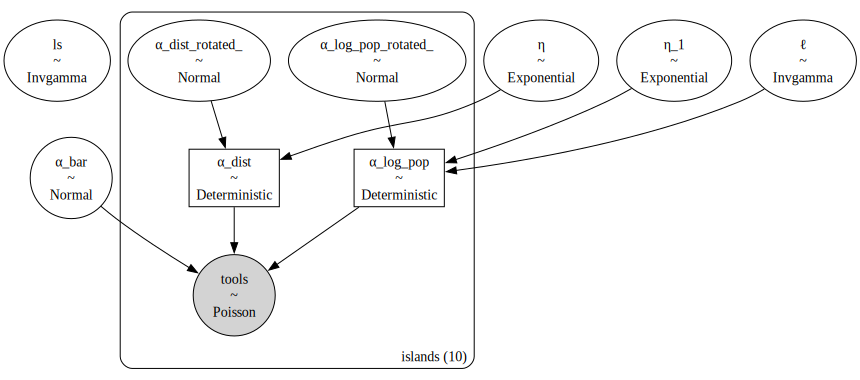

In [16]:
pm.model_to_graphviz(islands_model)

In [17]:
with islands_model:
    idata = pm.sample(random_seed=random_seed, target_accept=0.99)
    idata.extend(
        pm.sample_posterior_predictive(idata, random_seed=random_seed)
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α_bar, η, ls, α_dist_rotated_, η_1, ℓ, α_log_pop_rotated_]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 38 seconds.
Sampling: [tools]


Output()

Plot the posterior draws for the covariance of the log_population

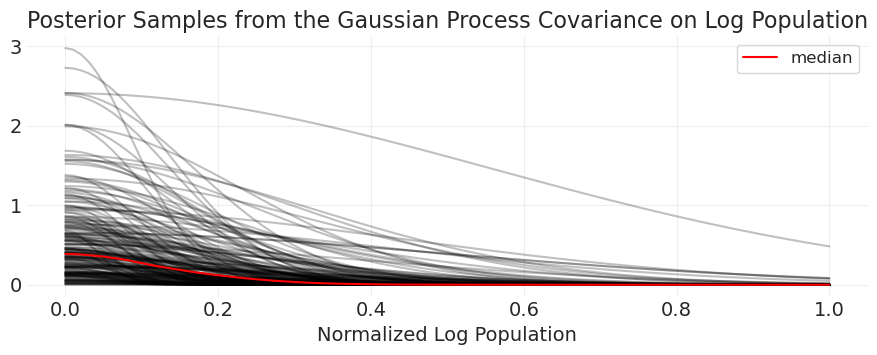

In [18]:
_, ax = plt.subplots(figsize=(9, 3))

posterior_hwb6 = idata.posterior.stack(dims=("chain", "draw"))

Npts = 100
log_pops_x = np.linspace(0, 1, Npts)

η_1 = posterior_hwb6["η_1"].values
ℓ = posterior_hwb6["ℓ"].values

cov_ = η_1[:, None] * np.exp(-log_pops_x**2 /(2 * ℓ[:, None]**2))

median_cov = np.median(cov_, axis=0)

for i in np.arange(0, cov_.shape[0], 20):
    ax.plot(log_pops_x, cov_[i, :], alpha=0.25, color="k")

ax.plot(log_pops_x, median_cov, color="red", label="median")
ax.set_xlabel("Normalized Log Population")
ax.set_title("Posterior Samples from the Gaussian Process Covariance on Log Population")
ax.legend()
plt.show()

Plot of total tools versus log pop

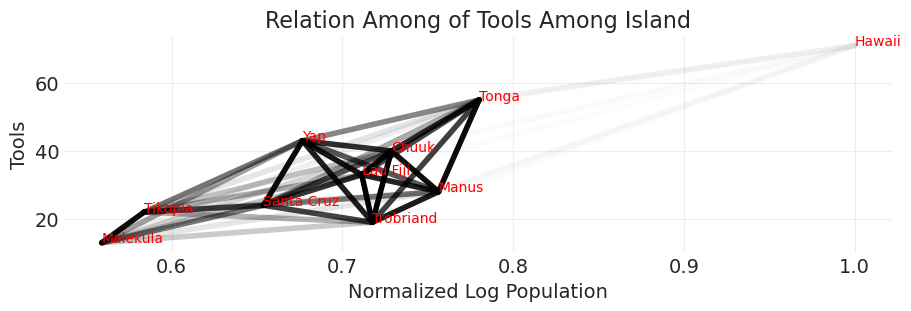

In [19]:
fig, ax = plt.subplots(figsize=(9., 3.))
logpop_dist = islands_df["logpop"].values - islands_df["logpop"].values[:, None]
Σ = np.median(η_1[:, None, None] * np.exp(-logpop_dist**2 / (2 * ℓ[:, None, None]**2)), axis=0)
Σ_post = np.diag(np.diag(Σ)**-0.5)
ρ = Σ_post @ Σ @ Σ_post

for i, text in enumerate(islands):

    ax.text(islands_df["logpop"][i], islands_df["total_tools"][i], text, color="red")


for i in range(10):
    for j in range(i, 10):
        ax.plot((islands_df["logpop"][i], islands_df["logpop"][j]),
                (islands_df["total_tools"][i], islands_df["total_tools"][j]),
                alpha= ρ[i, j]**2, 
                lw=4,
                color="k"
               )
ax.set_xlabel("Normalized Log Population")
ax.set_ylabel("Tools")
ax.set_title("Relation Among of Tools Among Island")
plt.show()